# Code quality metrics

Maintainability, complexity, coupling, inheritance and size of the code each model produced, from `MetricsResults/`, with the documented GREEN/YELLOW/RED thresholds drawn behind every distribution.

In [1]:
STORY_ID = "CPD-LC-001-009"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import tdd_results as tdd

tdd.setup_theme()
# Clear the per-session label cache and warning list first: re-running this
# cell after dropping new results into the trees would otherwise reuse stale
# model labels and count the same load warning once per re-run.
tdd.reset_caches()
data = tdd.load_all(STORY_ID)
MODELS = tdd.discover_models(STORY_ID)
if not MODELS:
    print(f"no results found for {STORY_ID!r}; stories present in the result "
          f"trees: {tdd.discover_stories()}")
PAL = tdd.model_palette(MODELS)        # fixed model -> color, used everywhere
HUE = list(PAL)                        # fixed hue_order, used everywhere

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
print(f"story: {STORY_ID} | models: {MODELS}")
print("palette:", PAL)
if tdd.load_warnings:
    print(f"{len(tdd.load_warnings)} load warnings -> tdd.load_warnings")

story: CPD-LC-001-009 | models: ['Kimi-K2.5', 'Qwen3.7-max']
palette: {'Kimi-K2.5': '#2a78d6', 'Qwen3.7-max': '#1baf7a'}
7 load warnings -> tdd.load_warnings


## Data integrity gate

Identity drift, evidence and metric signal, checked before the charts.


In [3]:
summ = tdd.iteration_summary(STORY_ID, data)
sig = tdd.discrimination(summ)
drift = tdd.audit_identity(STORY_ID)
dead = sig[sig["status"].isin(["ABSENT", "ALL-NA", "CONSTANT"])]
print(f"identity : {len(drift)} disagreements, "
      f"{(~drift['reconciles']).sum() if not drift.empty else 0} unreconcilable")
print(f"signal   : {len(sig) - len(dead)}/{len(sig)} metrics discriminate")
if not dead.empty:
    display(dead)


identity : 0 disagreements, 0 unreconcilable
signal   : 18/24 metrics discriminate


,metric,family,provenance,status,distinct,na_share
3,e2e_probe_pass_rate,B behavioural,tool-measured,CONSTANT,1,0.0
9,red_first,C convergence,tool-measured,CONSTANT,1,0.0
11,evidence_completeness,E evidence,derived,CONSTANT,1,0.0
16,ref_all_green,Q quality,self-reported,CONSTANT,1,0.0
19,layer_balance,V verification,tool-measured,CONSTANT,1,0.0
20,layer_coverage,V verification,tool-measured,CONSTANT,1,0.0


## Metric distributions vs thresholds (type level, final runs)

Each point is one type in one iteration's final snapshot. Background bands
are the documented GREEN/YELLOW/RED thresholds — distance into a band
matters, not just the flag.

**Chart columns** — four panels, one per metric: `model` (x); y — the type-level metric value in final snapshots, all runs pooled (`mi` maintainability index, 0–100, higher is better; `cc` cyclomatic complexity, `coupling` class coupling, `dit` depth of inheritance — lower is better); dots — types; box — median/IQR; background bands — the documented GREEN/YELLOW/RED thresholds.

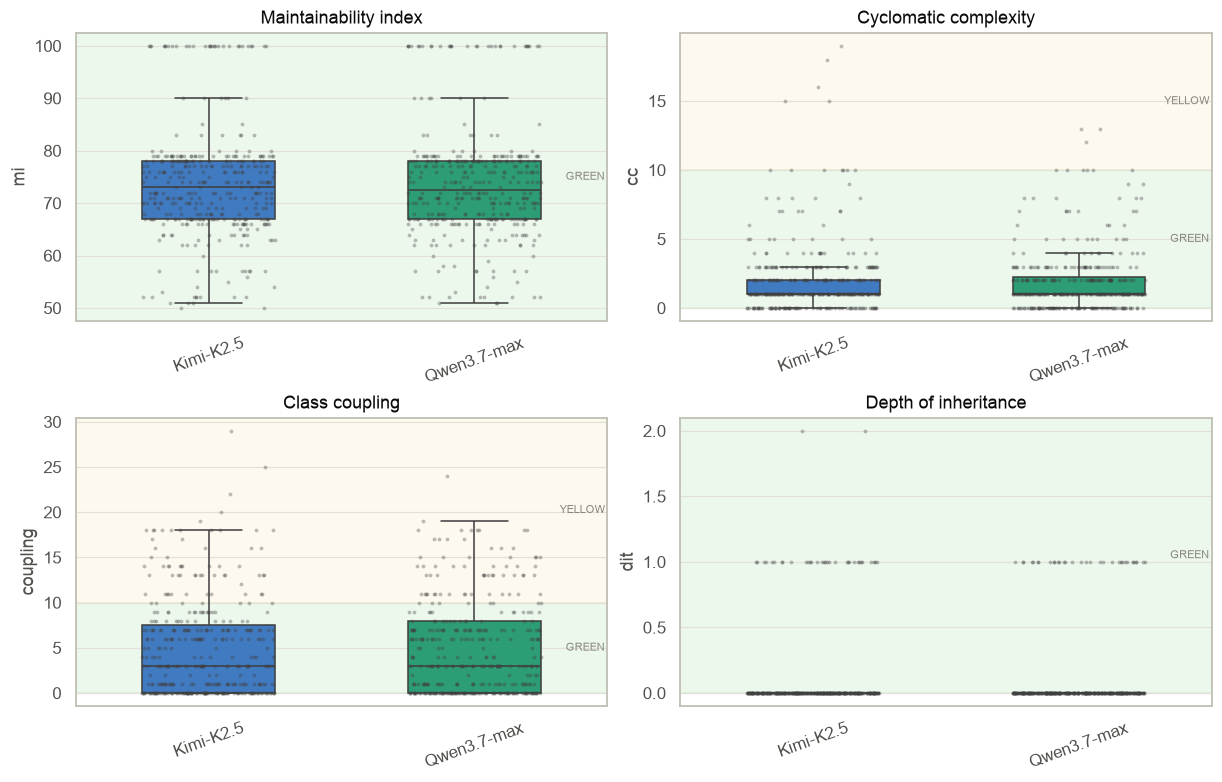

In [4]:
mt = tdd.finals(data["metrics_types"])
if mt.empty:
    print("No metrics data.")
else:
    panels = [("mi", "Maintainability index"), ("cc", "Cyclomatic complexity"),
              ("coupling", "Class coupling"), ("dit", "Depth of inheritance")]
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    for ax, (col, name) in zip(axes.flat, panels):
        sns.boxplot(data=mt, x="model", y=col, hue="model", order=HUE,
                    hue_order=HUE, palette=PAL, legend=False, width=0.5,
                    showfliers=False, ax=ax)
        sns.stripplot(data=mt, x="model", y=col, order=HUE, color=".25",
                      size=2.5, alpha=0.35, jitter=0.25, ax=ax)
        tdd.add_threshold_bands(ax, col)
        ax.set_title(name)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20)

## Flag composition per metric

Share of types in each flag color (counts annotated). A model can have a
good median and still ship YELLOW/RED outliers — this shows the tail.

**Chart columns** — one panel per metric (`MI`, `CC`, `Coupling`, `DIT`): `model` (y); x — share of that model's types (0–1) whose flag is GREEN / YELLOW / RED (segment color); segment number — the absolute type count behind the share.

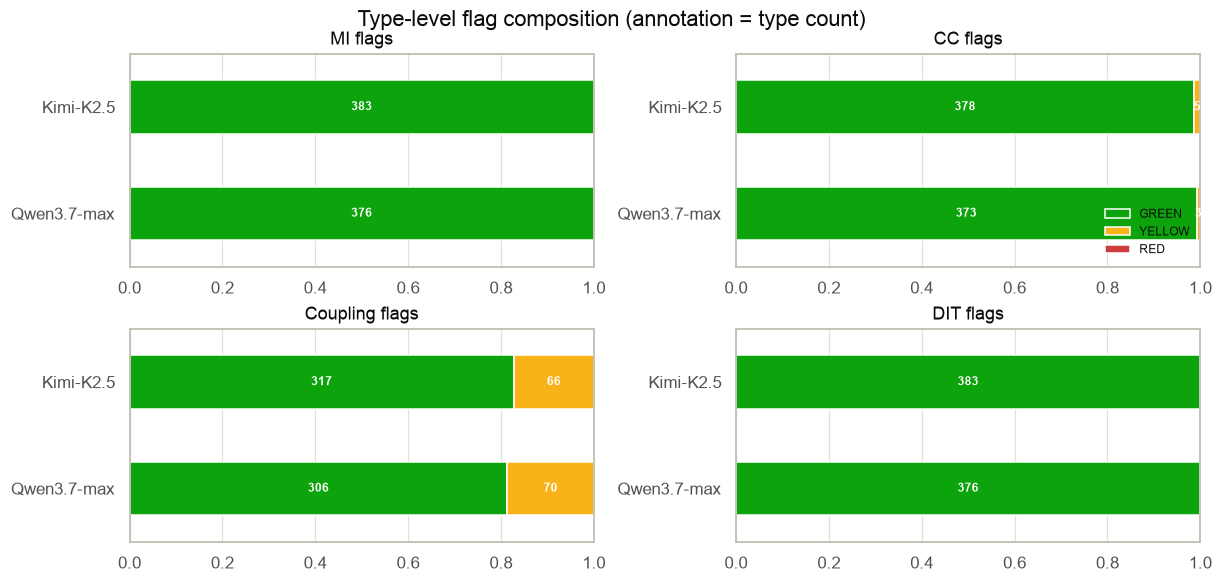

In [5]:
if mt.empty:
    print("No metrics data.")
else:
    flags = [("mi_flag", "MI"), ("cc_flag", "CC"),
             ("coupling_flag", "Coupling"), ("dit_flag", "DIT")]
    flag_order = ["GREEN", "YELLOW", "RED"]
    fig, axes = plt.subplots(2, 2, figsize=(11, 5))
    for ax, (col, name) in zip(axes.flat, flags):
        ct = (pd.crosstab(mt["model"], mt[col])
                .reindex(index=HUE, columns=flag_order, fill_value=0))
        frac = ct.div(ct.sum(axis=1), axis=0)
        frac.plot(kind="barh", stacked=True, ax=ax, legend=False,
                  color=[tdd.STATUS_COLORS[f] for f in flag_order])
        for container, flag in zip(ax.containers, flag_order):
            labels = [f"{int(v)}" if v else "" for v in ct[flag]]
            ax.bar_label(container, labels=labels, label_type="center",
                         fontsize=8, color="white", fontweight="bold")
        ax.set_title(f"{name} flags")
        ax.set_xlim(0, 1)
        ax.set_ylabel("")
        ax.invert_yaxis()
    axes.flat[1].legend(loc="lower right", fontsize=8)
    fig.suptitle("Type-level flag composition (annotation = type count)", y=1.03)

## Method-level hotspots

Worst methods per model across final snapshots (a method is counted once, at
its worst value). Bar color = its flag. These are the concrete places a
reviewer would push back on.

**Chart columns** — two figures (highest `cc`, lowest `mi`), one panel per model: y — the method as `Type.method` (truncated to 48 chars); x — the method's worst metric value across final snapshots (each method counted once); bar color — the GREEN/YELLOW/RED flag of that value.

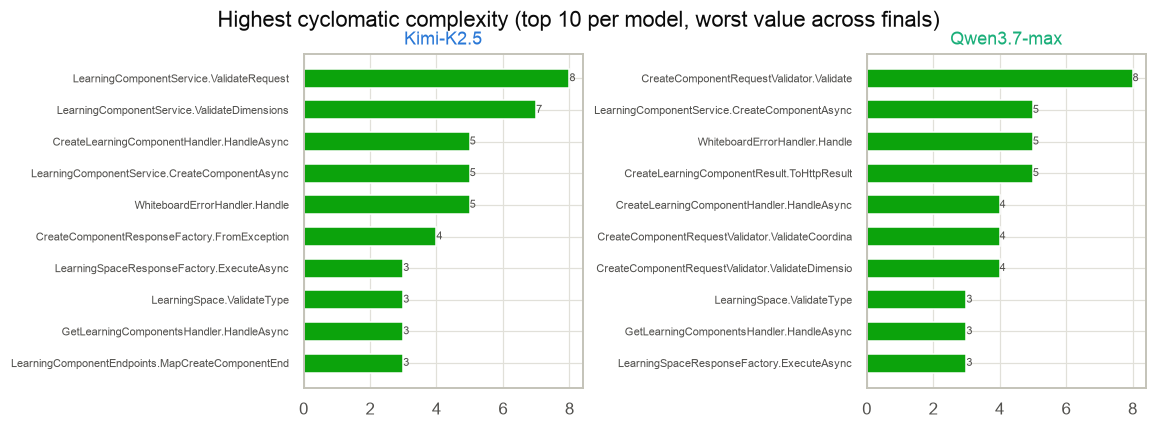

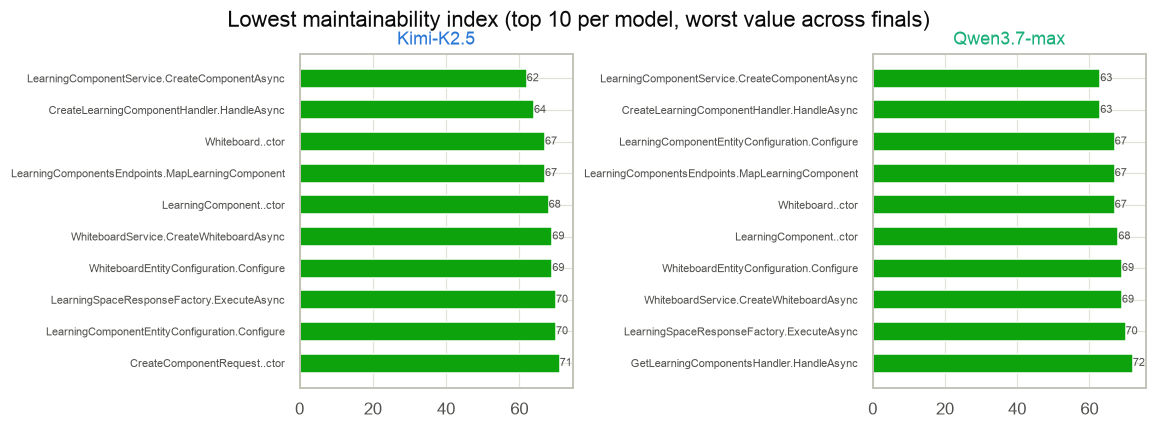

In [6]:
mm = tdd.finals(data["metrics_methods"]).copy()
if mm.empty:
    print("No method-level metrics.")
else:
    mm["label"] = (mm["type"] + "." + mm["method"].str.split("(").str[0]).str.slice(0, 48)

    def hotspots(df, col, ascending, n=10):
        idx = (df.groupby("label")[col].idxmin() if ascending
               else df.groupby("label")[col].idxmax())
        best = df.loc[idx]
        return best.sort_values(col, ascending=ascending).head(n).iloc[::-1]

    for col, title, ascending in [("cc", "Highest cyclomatic complexity", False),
                                  ("mi", "Lowest maintainability index", True)]:
        fig, axes = plt.subplots(1, len(HUE), figsize=(5.2 * len(HUE), 3.6))
        for ax, m in zip(np.atleast_1d(axes), HUE):
            sub = hotspots(mm[mm["model"] == m], col, ascending)
            flag_col = f"{col}_flag"
            ax.barh(sub["label"], sub[col],
                    color=[tdd.STATUS_COLORS.get(f, "#898781") for f in sub[flag_col]],
                    height=0.6)
            ax.bar_label(ax.containers[0], fontsize=7, color=tdd.INK["secondary"])
            ax.set_title(m, color=PAL[m])
            ax.tick_params(axis="y", labelsize=7)
        fig.suptitle(f"{title} (top 10 per model, worst value across finals)", y=1.04)

## Code size

Left: total source lines of the final snapshot per iteration — how much code
each model writes for the same story. Right: source vs executable lines per
type — density of the code produced.

**Chart columns** — left: `iteration` (x); `total source lines` (y) — sum over the final snapshot's types; color — model. Right: one point per type, `source_lines` (x) vs `executable_lines` (y) — the closer to the diagonal, the denser the type; color — model.

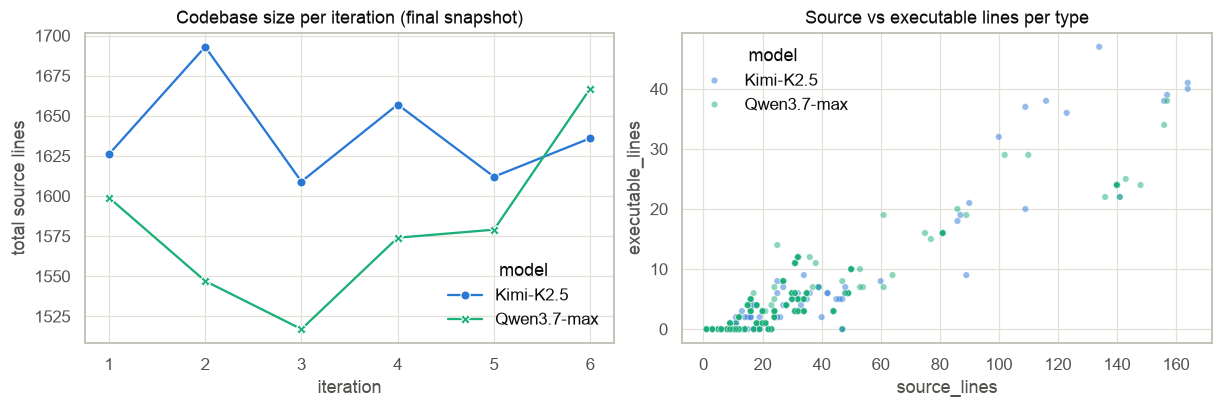

In [7]:
if mt.empty:
    print("No metrics data.")
else:
    size = (mt.groupby(["model", "iteration"], as_index=False)
              [["source_lines", "executable_lines"]].sum())
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
    sns.lineplot(data=size, x="iteration", y="source_lines", hue="model",
                 style="model", hue_order=HUE, style_order=HUE, palette=PAL,
                 markers=True, dashes=False, estimator=None, ax=ax1)
    ax1.set_ylabel("total source lines")
    ax1.set_title("Codebase size per iteration (final snapshot)")
    sns.scatterplot(data=mt, x="source_lines", y="executable_lines",
                    hue="model", hue_order=HUE, palette=PAL, alpha=0.5,
                    s=18, ax=ax2)
    ax2.set_title("Source vs executable lines per type")

## Refactoring: measured movement, and what the agent claimed

Did refactoring actually improve the code? Two answers are shown side by side
because they do not always agree.

The **measured** movement compares the first and last `metrics-summary.json`
snapshot of each run — files the analyser tool wrote. The **claimed** outcome
is the refactoring stage's own `allGreenAchieved` and `loopIterationsPerformed`,
written by the agent about its own work. A run claiming all-green while the
measured coupling drop is zero is the disagreement worth investigating, and
only the measured side can show it.

**Chart & table columns** — left: `worst-type class coupling`, first → last
snapshot per run, dodged by model, with the documented GREEN/YELLOW/RED bands;
middle: `green share gained` — change in the share of types GREEN on all four
flags; right: `worst-type MI gained`. Table: measured movement per run
(`worst_coupling_drop`, `green_share_gain`, `min_mi_gain`, `metrics_snapshots`)
beside the claimed `ref_all_green` and `ref_loop_iterations`, with `disagrees`
flagging a claimed all-green that produced no measurable improvement.


,model,iteration,metrics_snapshots,worst_coupling_drop,green_share_gain,min_mi_gain,ref_all_green,ref_loop_iterations,max_coupling,disagrees
0,Kimi-K2.5,1,2,0,0.000,0,False,1.0,20,False
1,Kimi-K2.5,2,3,0,0.000,-1,False,2.0,29,False
2,Kimi-K2.5,3,8,2,0.021,0,False,6.0,19,False
3,Kimi-K2.5,4,10,0,0.034,0,False,8.0,18,False
4,Kimi-K2.5,5,2,0,0.000,0,False,1.0,18,False
5,Kimi-K2.5,6,3,0,0.000,0,False,2.0,25,False
6,Qwen3.7-max,1,4,0,0.003,0,False,3.0,24,False
7,Qwen3.7-max,2,3,0,0.000,0,False,2.0,18,False
8,Qwen3.7-max,3,3,4,-0.013,0,False,2.0,18,False
9,Qwen3.7-max,4,4,0,0.000,0,False,3.0,19,False


every claimed all-green is backed by measurable improvement


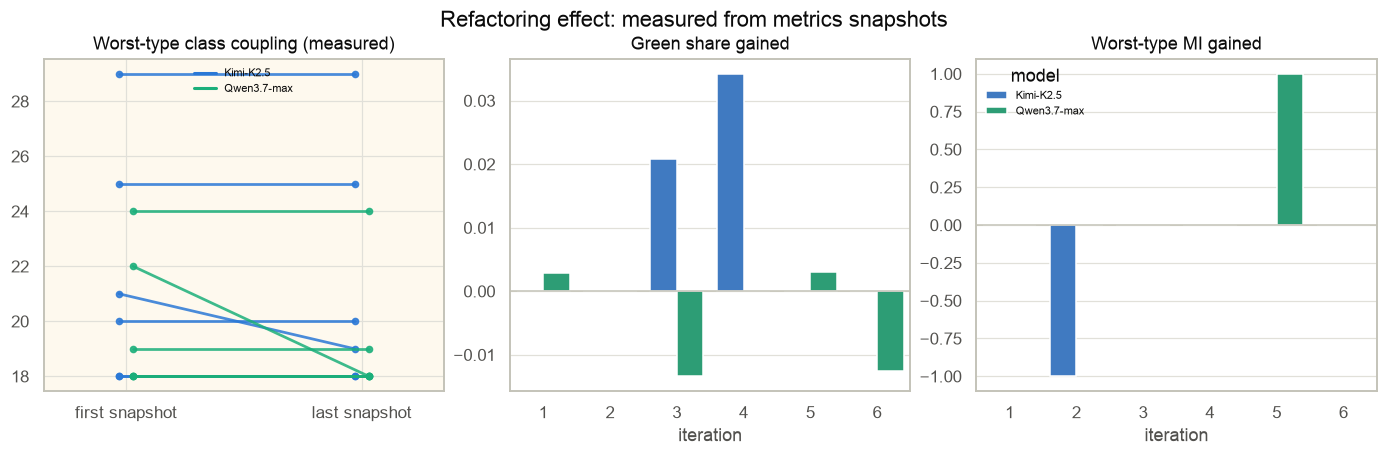

In [8]:
qm = summ[["model", "iteration", "metrics_snapshots", "worst_coupling_drop",
           "green_share_gain", "min_mi_gain", "ref_all_green",
           "ref_loop_iterations", "max_coupling"]].copy()
mts = data["metrics_types"]

if qm.empty or mts.empty:
    print("No metrics snapshots for this section.")
else:
    # first/last worst-type coupling per run, straight from the snapshots
    snap = (mts.groupby(["model", "iteration", "ts"])["coupling"].max()
               .reset_index().sort_values(["model", "iteration", "ts"]))
    ends = (snap.groupby(["model", "iteration"])["coupling"]
                .agg(first="first", last="last").reset_index())

    offsets = {m: (i - (len(HUE) - 1) / 2) * 0.06 for i, m in enumerate(HUE)}
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))

    for _, r in ends.iterrows():
        dx = offsets[r["model"]]
        axes[0].plot([dx, 1 + dx], [r["first"], r["last"]], color=PAL[r["model"]],
                     alpha=0.85, lw=1.8, marker="o", markersize=4)
    axes[0].set_xlim(-0.35, 1.35)
    axes[0].set_xticks([0, 1], ["first snapshot", "last snapshot"])
    tdd.add_threshold_bands(axes[0], "coupling", label=False)
    axes[0].set_title("Worst-type class coupling (measured)")

    for ax, col, title in ((axes[1], "green_share_gain", "Green share gained"),
                           (axes[2], "min_mi_gain", "Worst-type MI gained")):
        sns.barplot(data=qm, x="iteration", y=col, hue="model", hue_order=HUE,
                    palette=PAL, errorbar=None, ax=ax)
        ax.axhline(0, color=tdd.INK["baseline"], lw=1)
        ax.set_title(title)
        ax.set_ylabel("")
        ax.legend().remove() if ax is axes[1] else ax.legend(title="model", fontsize=7)

    handles = [plt.Line2D([], [], color=PAL[m], lw=2, label=m) for m in HUE]
    axes[0].legend(handles=handles, fontsize=7)
    fig.suptitle("Refactoring effect: measured from metrics snapshots", y=1.05)

    # A claimed all-green that moved nothing measurable.
    qm["disagrees"] = (qm["ref_all_green"].eq(True)
                       & qm["worst_coupling_drop"].fillna(0).le(0)
                       & qm["green_share_gain"].fillna(0).le(0))
    display(qm.round(3).sort_values(["model", "iteration"]).reset_index(drop=True))
    n_dis = int(qm["disagrees"].sum())
    if n_dis:
        print(f"{n_dis} run(s) claimed allGreenAchieved with no measurable "
              f"improvement — see the `disagrees` column")
    else:
        print("every claimed all-green is backed by measurable improvement")


## Remaining violations after refactoring

What still blocked all-green when the loop stopped, by metric. Details
below — these name the exact types to inspect.

**Chart & table columns** — chart: one panel per `metric`; `model` (x); `violations` (y) — violations still open when the loop stopped, summed over runs. Table: `model`, `iteration` — the run; `type` — the offending type; `metric` — which threshold it breaks; `value` — the measured value; `flag` — YELLOW/RED severity.

,model,iteration,type,metric,value,flag
0,Kimi-K2.5,1,LearningComponentService,CC,16,YELLOW
1,Kimi-K2.5,1,LearningComponentService,Coupling,20,YELLOW
2,Kimi-K2.5,1,SqlLearningComponentRepository,Coupling,14,YELLOW
3,Kimi-K2.5,1,CreateLearningComponentHandler,Coupling,16,YELLOW
4,Kimi-K2.5,2,LearningComponentService,CC,18,YELLOW
5,Kimi-K2.5,2,LearningComponentService,Coupling,22,YELLOW
6,Kimi-K2.5,2,CreateLearningComponentHandler,CC,15,YELLOW
7,Kimi-K2.5,2,CreateLearningComponentHandler,Coupling,29,YELLOW
8,Kimi-K2.5,2,SqlLearningComponentRepository,Coupling,14,YELLOW
9,Kimi-K2.5,3,LearningComponentEndpoints,Coupling,19,YELLOW


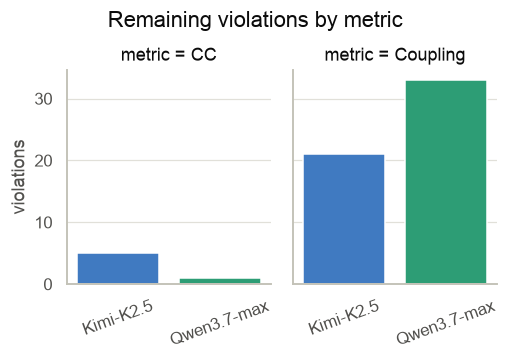

In [9]:
v = data["violations"]
if v.empty:
    print("No remaining violations — every refactoring loop ended all-green.")
else:
    g = sns.catplot(data=v, kind="count", x="model", col="metric", order=HUE,
                    hue="model", hue_order=HUE, palette=PAL, legend=False,
                    height=3, aspect=0.8)
    g.set_axis_labels("", "violations")
    g.set_xticklabels(rotation=20)
    g.figure.suptitle("Remaining violations by metric", y=1.05)
    display(v.sort_values(["model", "iteration"])
             [["model", "iteration", "type", "metric", "value", "flag"]]
             .reset_index(drop=True))

## Sanity checks

In [10]:
if not mt.empty:
    assert mt["mi"].dropna().between(0, 100).all()
    assert set(mt["mi_flag"].dropna().unique()) <= {"GREEN", "YELLOW", "RED"}
assert summ["model"].isin(HUE).all(), "identity drift leaked into the master table"
assert drift.empty or drift["reconciles"].all(), "misfiled results present"
if not qm.empty:
    assert qm["metrics_snapshots"].fillna(0).ge(1).all(), \
        "every run needs at least one metrics snapshot"
    assert qm["green_share_gain"].dropna().between(-1, 1).all()
print(f"sanity checks passed | {len(tdd.load_warnings)} load warnings | "
      f"{len(dead)} metrics without signal")


sanity checks passed | 16 load warnings | 6 metrics without signal
